# 04 ML Stockout and Reorder Training

This notebook trains two classification models from the Gold inventory tables.

Model 1 predicts stockout risk level.

Model 2 predicts whether a product needs reorder.

The notebook uses PySpark, pandas, scikit-learn, and MLflow experiment tracking.

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA retail_capstone")

spark.sql("SELECT current_catalog(), current_schema()").show()

+-----------------+----------------+
|current_catalog()|current_schema()|
+-----------------+----------------+
|        workspace| retail_capstone|
+-----------------+----------------+



In [0]:
import mlflow
import mlflow.sklearn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pyspark.sql.functions import col, when, lit, rand, round

In [0]:
stockout_df = spark.table("workspace.retail_capstone.gold_stockout_risk")
reorder_df = spark.table("workspace.retail_capstone.gold_reorder_recommendations")
inventory_value_df = spark.table("workspace.retail_capstone.gold_inventory_value")
sales_velocity_df = spark.table("workspace.retail_capstone.gold_product_sales_velocity")

In [0]:
display(stockout_df)

stock_code,product_name,category,brand,warehouse_id,warehouse_name,available_stock,avg_daily_sales,days_of_inventory_remaining,supplier_name,lead_time_days,reliability_score,stockout_risk_level
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,Home & Living,WarmHome,WH002,Berlin Distribution Hub,25,17.91,1.4,WarmHome Manufacturing,14,0.91,High Risk
85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,210,120.15,1.75,Global Home Supplies,7,0.94,High Risk
84029E,RED WOOLLY HOTTIE WHITE HEART,Home & Living,WarmHome,WH002,Berlin Distribution Hub,48,38.24,1.26,WarmHome Manufacturing,14,0.91,High Risk
84879,ASSORTED COLOUR BIRD ORNAMENT,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,100,117.5,0.85,Global Home Supplies,7,0.94,High Risk
71053,WHITE METAL LANTERN,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,75,10.41,7.2,Global Home Supplies,7,0.94,Medium Risk
21730,GLASS STAR FROSTED T-LIGHT HOLDER,Home Decor,GlassWorks,WH001,Nuremberg Fulfillment Center,110,6.29,17.49,GlassWorks Studio,9,0.89,Low Risk
22752,SET 7 BABUSHKA NESTING BOXES,Gifts,GiftCraft,WH003,Cologne Regional Warehouse,20,9.2,2.17,GiftCraft Wholesale,12,0.86,High Risk
84406B,CREAM CUPID HEARTS COAT HANGER,Home Decor,Generic Home,WH002,Berlin Distribution Hub,40,12.52,3.19,DecorCraft Europe,10,0.88,High Risk
22633,HAND WARMER UNION JACK,Accessories,WarmHome,WH003,Cologne Regional Warehouse,60,45.52,1.32,WarmHome Manufacturing,14,0.91,High Risk
22632,HAND WARMER RED POLKA DOT,Accessories,WarmHome,WH003,Cologne Regional Warehouse,50,43.69,1.14,WarmHome Manufacturing,14,0.91,High Risk


In [0]:
display(reorder_df)

stock_code,product_name,category,brand,warehouse_id,warehouse_name,available_stock,reorder_level,reorder_quantity,recommended_reorder_quantity,supplier_name,lead_time_days,reorder_flag
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,Home & Living,WarmHome,WH002,Berlin Distribution Hub,25,50,120,120,WarmHome Manufacturing,14,Reorder Needed
85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,210,100,300,0,Global Home Supplies,7,No Reorder Needed
84029E,RED WOOLLY HOTTIE WHITE HEART,Home & Living,WarmHome,WH002,Berlin Distribution Hub,48,50,120,120,WarmHome Manufacturing,14,Reorder Needed
84879,ASSORTED COLOUR BIRD ORNAMENT,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,100,90,250,0,Global Home Supplies,7,No Reorder Needed
71053,WHITE METAL LANTERN,Home Decor,Generic Home,WH001,Nuremberg Fulfillment Center,75,80,200,200,Global Home Supplies,7,Reorder Needed
21730,GLASS STAR FROSTED T-LIGHT HOLDER,Home Decor,GlassWorks,WH001,Nuremberg Fulfillment Center,110,70,180,0,GlassWorks Studio,9,No Reorder Needed
22752,SET 7 BABUSHKA NESTING BOXES,Gifts,GiftCraft,WH003,Cologne Regional Warehouse,20,40,100,100,GiftCraft Wholesale,12,Reorder Needed
84406B,CREAM CUPID HEARTS COAT HANGER,Home Decor,Generic Home,WH002,Berlin Distribution Hub,40,60,150,150,DecorCraft Europe,10,Reorder Needed
22633,HAND WARMER UNION JACK,Accessories,WarmHome,WH003,Cologne Regional Warehouse,60,120,300,300,WarmHome Manufacturing,14,Reorder Needed
22632,HAND WARMER RED POLKA DOT,Accessories,WarmHome,WH003,Cologne Regional Warehouse,50,120,300,300,WarmHome Manufacturing,14,Reorder Needed


In [0]:
print("Stockout rows:", stockout_df.count())
print("Reorder rows:", reorder_df.count())
print("Inventory value rows:", inventory_value_df.count())
print("Sales velocity rows:", sales_velocity_df.count())

Stockout rows: 10
Reorder rows: 10
Inventory value rows: 10
Sales velocity rows: 3667


In [0]:
base_df = stockout_df.select(
    "stock_code",
    "product_name",
    "category",
    "brand",
    "warehouse_id",
    "available_stock",
    "avg_daily_sales",
    "days_of_inventory_remaining",
    "lead_time_days",
    "reliability_score",
    "stockout_risk_level"
)

In [0]:
expanded_stockout_df = base_df.crossJoin(
    spark.range(1, 101).withColumnRenamed("id", "simulation_id")
).withColumn(
    "available_stock",
    round(col("available_stock") * (lit(0.5) + rand()), 0)
).withColumn(
    "avg_daily_sales",
    round(col("avg_daily_sales") * (lit(0.5) + rand()), 2)
).withColumn(
    "lead_time_days",
    round(col("lead_time_days") * (lit(0.8) + rand() * lit(0.5)), 0)
).withColumn(
    "reliability_score",
    round(col("reliability_score") * (lit(0.9) + rand() * lit(0.2)), 2)
)

In [0]:
expanded_stockout_df = expanded_stockout_df.withColumn(
    "days_of_inventory_remaining",
    when(
        col("avg_daily_sales") > 0,
        round(col("available_stock") / col("avg_daily_sales"), 2)
    ).otherwise(None)
)

In [0]:
expanded_stockout_df = expanded_stockout_df.withColumn(
    "stockout_risk_level",
    when(col("avg_daily_sales") == 0, "No Recent Sales")
    .when(col("days_of_inventory_remaining") <= col("lead_time_days"), "High Risk")
    .when(col("days_of_inventory_remaining") <= col("lead_time_days") + 7, "Medium Risk")
    .otherwise("Low Risk")
)

In [0]:
expanded_stockout_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("workspace.retail_capstone.ml_stockout_training_data")

In [0]:
display(spark.table("workspace.retail_capstone.ml_stockout_training_data"))

stock_code,product_name,category,brand,warehouse_id,available_stock,avg_daily_sales,days_of_inventory_remaining,lead_time_days,reliability_score,stockout_risk_level,simulation_id
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,Home & Living,WarmHome,WH002,16.0,20.29,0.79,15.0,0.88,High Risk,13
85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home Decor,Generic Home,WH001,224.0,82.19,2.73,7.0,0.95,High Risk,14
84029E,RED WOOLLY HOTTIE WHITE HEART,Home & Living,WarmHome,WH002,64.0,34.4,1.86,17.0,0.82,High Risk,15
84879,ASSORTED COLOUR BIRD ORNAMENT,Home Decor,Generic Home,WH001,64.0,138.1,0.46,8.0,0.93,High Risk,16
71053,WHITE METAL LANTERN,Home Decor,Generic Home,WH001,52.0,10.39,5.0,8.0,0.87,High Risk,17
21730,GLASS STAR FROSTED T-LIGHT HOLDER,Home Decor,GlassWorks,WH001,119.0,4.54,26.21,8.0,0.8,Low Risk,18
22752,SET 7 BABUSHKA NESTING BOXES,Gifts,GiftCraft,WH003,16.0,12.19,1.31,11.0,0.86,High Risk,19
84406B,CREAM CUPID HEARTS COAT HANGER,Home Decor,Generic Home,WH002,45.0,10.56,4.26,13.0,0.9,High Risk,20
22633,HAND WARMER UNION JACK,Accessories,WarmHome,WH003,84.0,57.54,1.46,12.0,0.99,High Risk,21
22632,HAND WARMER RED POLKA DOT,Accessories,WarmHome,WH003,73.0,22.98,3.18,16.0,0.96,High Risk,22


In [0]:
reorder_base_df = reorder_df.select(
    "stock_code",
    "product_name",
    "category",
    "brand",
    "warehouse_id",
    "available_stock",
    "reorder_level",
    "reorder_quantity",
    "lead_time_days",
    "reorder_flag"
)

In [0]:
expanded_reorder_df = reorder_base_df.crossJoin(
    spark.range(1, 101).withColumnRenamed("id", "simulation_id")
).withColumn(
    "available_stock",
    round(col("available_stock") * (lit(0.5) + rand()), 0)
).withColumn(
    "reorder_level",
    round(col("reorder_level") * (lit(0.8) + rand() * lit(0.5)), 0)
).withColumn(
    "reorder_quantity",
    round(col("reorder_quantity") * (lit(0.8) + rand() * lit(0.5)), 0)
).withColumn(
    "lead_time_days",
    round(col("lead_time_days") * (lit(0.8) + rand() * lit(0.5)), 0)
)

In [0]:
expanded_reorder_df = expanded_reorder_df.withColumn(
    "reorder_flag",
    when(col("available_stock") <= col("reorder_level"), "Reorder Needed")
    .otherwise("No Reorder Needed")
)

In [0]:
expanded_reorder_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("workspace.retail_capstone.ml_reorder_training_data")

In [0]:
display(spark.table("workspace.retail_capstone.ml_reorder_training_data"))

stock_code,product_name,category,brand,warehouse_id,available_stock,reorder_level,reorder_quantity,lead_time_days,reorder_flag,simulation_id
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,Home & Living,WarmHome,WH002,37.0,42.0,110.0,13.0,Reorder Needed,38
85123A,WHITE HANGING HEART T-LIGHT HOLDER,Home Decor,Generic Home,WH001,149.0,112.0,274.0,6.0,No Reorder Needed,39
84029E,RED WOOLLY HOTTIE WHITE HEART,Home & Living,WarmHome,WH002,28.0,48.0,111.0,12.0,Reorder Needed,40
84879,ASSORTED COLOUR BIRD ORNAMENT,Home Decor,Generic Home,WH001,133.0,103.0,287.0,9.0,No Reorder Needed,41
71053,WHITE METAL LANTERN,Home Decor,Generic Home,WH001,75.0,86.0,208.0,6.0,Reorder Needed,42
21730,GLASS STAR FROSTED T-LIGHT HOLDER,Home Decor,GlassWorks,WH001,81.0,69.0,155.0,11.0,No Reorder Needed,43
22752,SET 7 BABUSHKA NESTING BOXES,Gifts,GiftCraft,WH003,15.0,46.0,85.0,10.0,Reorder Needed,44
84406B,CREAM CUPID HEARTS COAT HANGER,Home Decor,Generic Home,WH002,21.0,76.0,192.0,10.0,Reorder Needed,45
22633,HAND WARMER UNION JACK,Accessories,WarmHome,WH003,39.0,155.0,308.0,17.0,Reorder Needed,46
22632,HAND WARMER RED POLKA DOT,Accessories,WarmHome,WH003,32.0,97.0,276.0,15.0,Reorder Needed,47


# ML Training Data Created

The original Gold inventory tables are small because this project uses sample data.

For ML practice, I created synthetically expanded training datasets from the Gold tables and inventory business rules.

Created ML feature tables:

- `ml_stockout_training_data`
- `ml_reorder_training_data`

These tables are used only for learning and demonstration purposes.

In [0]:
spark.sql("""
SHOW TABLES IN workspace.retail_capstone
""").show(truncate=False)

+---------------+----------------------------+-----------+
|database       |tableName                   |isTemporary|
+---------------+----------------------------+-----------+
|retail_capstone|bronze_inventory            |false      |
|retail_capstone|bronze_products             |false      |
|retail_capstone|bronze_sales                |false      |
|retail_capstone|bronze_suppliers            |false      |
|retail_capstone|bronze_warehouses           |false      |
|retail_capstone|curated_online_retail       |false      |
|retail_capstone|customer_summary            |false      |
|retail_capstone|daily_country_revenue       |false      |
|retail_capstone|gold_inventory_status       |false      |
|retail_capstone|gold_inventory_value        |false      |
|retail_capstone|gold_product_sales_velocity |false      |
|retail_capstone|gold_reorder_recommendations|false      |
|retail_capstone|gold_stockout_risk          |false      |
|retail_capstone|inventory_sample            |false     

# Exploratory Data Analysis

This section visualizes the ML training datasets to understand target distributions and feature behavior.

In [0]:
ml_stockout_df = spark.table("workspace.retail_capstone.ml_stockout_training_data")
ml_reorder_df = spark.table("workspace.retail_capstone.ml_reorder_training_data")

In [0]:
print("Stockout ML training rows:", ml_stockout_df.count())
print("Reorder ML training rows:", ml_reorder_df.count())

Stockout ML training rows: 1000
Reorder ML training rows: 1000


In [0]:
stockout_label_counts = ml_stockout_df.groupBy("stockout_risk_level").count()
display(stockout_label_counts)

stockout_risk_level,count
High Risk,867
Medium Risk,73
Low Risk,60


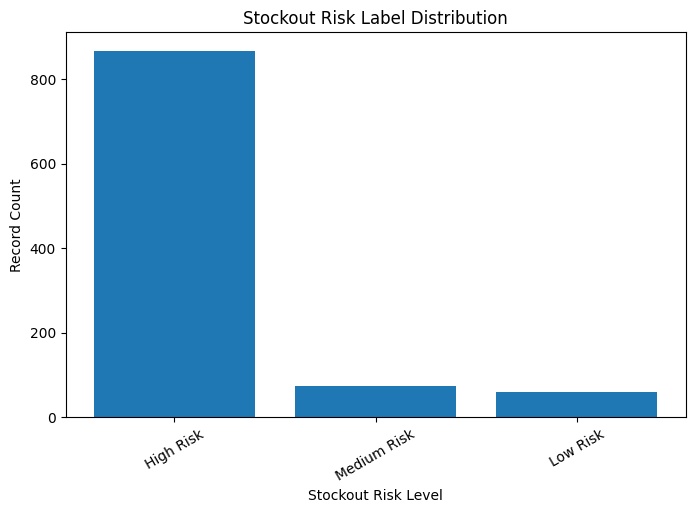

In [0]:
stockout_label_pd = stockout_label_counts.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(stockout_label_pd["stockout_risk_level"], stockout_label_pd["count"])
plt.xlabel("Stockout Risk Level")
plt.ylabel("Record Count")
plt.title("Stockout Risk Label Distribution")
plt.xticks(rotation=30)
plt.show()

In [0]:
reorder_label_counts = ml_reorder_df.groupBy("reorder_flag").count()
display(reorder_label_counts)

reorder_flag,count
No Reorder Needed,328
Reorder Needed,672


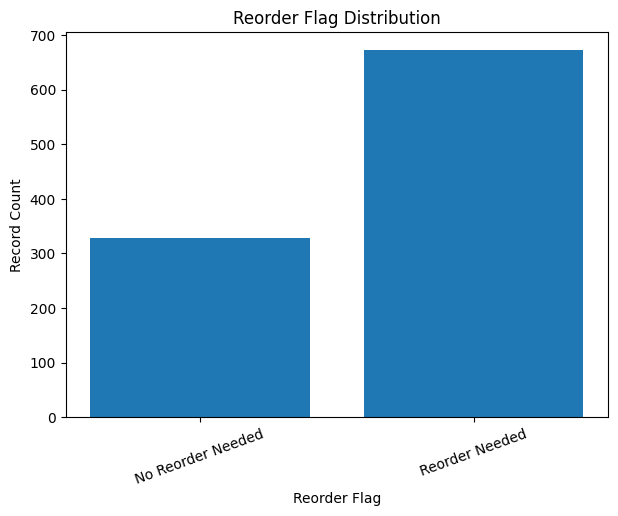

In [0]:
reorder_label_pd = reorder_label_counts.toPandas()

plt.figure(figsize=(7, 5))
plt.bar(reorder_label_pd["reorder_flag"], reorder_label_pd["count"])
plt.xlabel("Reorder Flag")
plt.ylabel("Record Count")
plt.title("Reorder Flag Distribution")
plt.xticks(rotation=20)
plt.show()

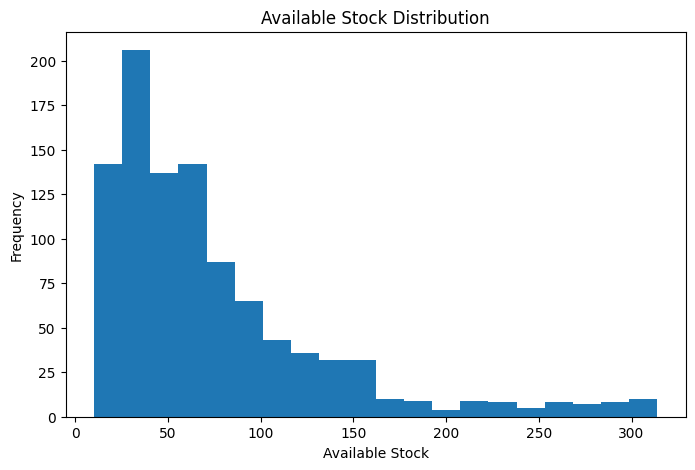

In [0]:
stock_pd = ml_stockout_df.select("available_stock").toPandas()

plt.figure(figsize=(8, 5))
plt.hist(stock_pd["available_stock"], bins=20)
plt.xlabel("Available Stock")
plt.ylabel("Frequency")
plt.title("Available Stock Distribution")
plt.show()

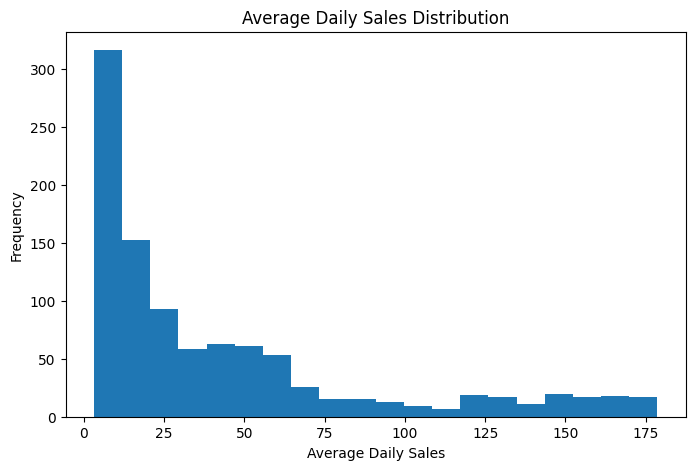

In [0]:
sales_pd = ml_stockout_df.select("avg_daily_sales").toPandas()

plt.figure(figsize=(8, 5))
plt.hist(sales_pd["avg_daily_sales"], bins=20)
plt.xlabel("Average Daily Sales")
plt.ylabel("Frequency")
plt.title("Average Daily Sales Distribution")
plt.show()

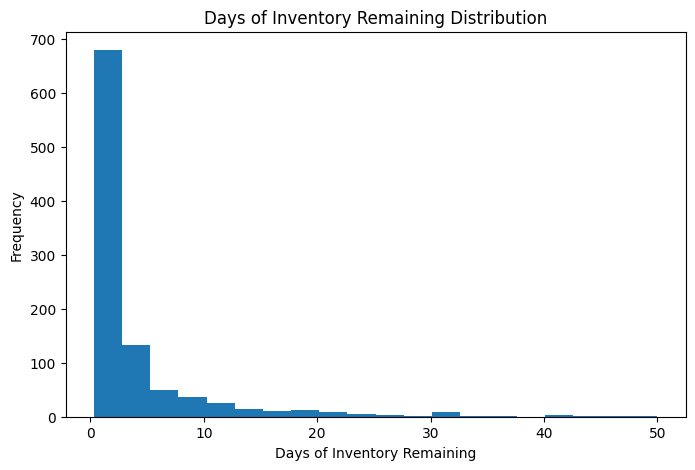

In [0]:
days_pd = ml_stockout_df.select("days_of_inventory_remaining").dropna().toPandas()

plt.figure(figsize=(8, 5))
plt.hist(days_pd["days_of_inventory_remaining"], bins=20)
plt.xlabel("Days of Inventory Remaining")
plt.ylabel("Frequency")
plt.title("Days of Inventory Remaining Distribution")
plt.show()

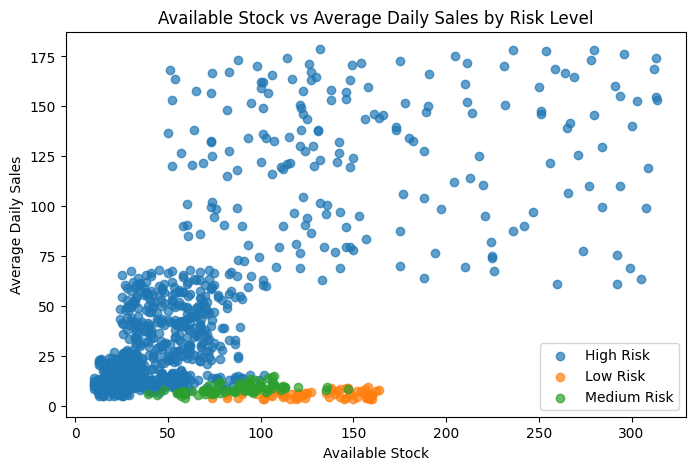

In [0]:
scatter_pd = ml_stockout_df.select(
    "available_stock",
    "avg_daily_sales",
    "stockout_risk_level"
).dropna().toPandas()

plt.figure(figsize=(8, 5))

for label in scatter_pd["stockout_risk_level"].unique():
    subset = scatter_pd[scatter_pd["stockout_risk_level"] == label]
    plt.scatter(
        subset["available_stock"],
        subset["avg_daily_sales"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Available Stock")
plt.ylabel("Average Daily Sales")
plt.title("Available Stock vs Average Daily Sales by Risk Level")
plt.legend()
plt.show()

# EDA Summary

The exploratory analysis shows how inventory and sales behavior relate to stockout risk and reorder decisions.

Key observations:

- The stockout risk label distribution shows how many examples belong to each risk class.
- The reorder flag distribution shows the balance between reorder-needed and no-reorder-needed records.
- Available stock and average daily sales are important because products with low stock and high demand are more likely to run out.
- Days of inventory remaining is a key business feature because it estimates how long current inventory can support demand.
- The scatter plot helps visualize the relationship between available stock, sales velocity, and risk level.

# Model 1: Stockout Risk Classifier

This model predicts the stockout risk level for a product based on inventory, sales velocity, supplier, and warehouse features.

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

import mlflow
import mlflow.sklearn

In [0]:
stockout_pd = ml_stockout_df.select(
    "available_stock",
    "avg_daily_sales",
    "days_of_inventory_remaining",
    "lead_time_days",
    "reliability_score",
    "category",
    "warehouse_id",
    "stockout_risk_level"
).dropna().toPandas()

display(stockout_pd.head())

available_stock,avg_daily_sales,days_of_inventory_remaining,lead_time_days,reliability_score,category,warehouse_id,stockout_risk_level
16.0,20.29,0.79,15.0,0.88,Home & Living,WH002,High Risk
224.0,82.19,2.73,7.0,0.95,Home Decor,WH001,High Risk
64.0,34.4,1.86,17.0,0.82,Home & Living,WH002,High Risk
64.0,138.1,0.46,8.0,0.93,Home Decor,WH001,High Risk
52.0,10.39,5.0,8.0,0.87,Home Decor,WH001,High Risk


In [0]:
stockout_pd["stockout_risk_level"].value_counts()

stockout_risk_level
High Risk      867
Medium Risk     73
Low Risk        60
Name: count, dtype: int64

In [0]:
stockout_features = [
    "available_stock",
    "avg_daily_sales",
    "days_of_inventory_remaining",
    "lead_time_days",
    "reliability_score",
    "category",
    "warehouse_id"
]

stockout_target = "stockout_risk_level"

X_stockout = stockout_pd[stockout_features]
y_stockout = stockout_pd[stockout_target]

In [0]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stockout,
    y_stockout,
    test_size=0.2,
    random_state=42,
    stratify=y_stockout
)

print("Training rows:", len(X_train_s))
print("Test rows:", len(X_test_s))

Training rows: 800
Test rows: 200


In [0]:
numeric_features_stockout = [
    "available_stock",
    "avg_daily_sales",
    "days_of_inventory_remaining",
    "lead_time_days",
    "reliability_score"
]

categorical_features_stockout = [
    "category",
    "warehouse_id"
]

stockout_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features_stockout),
        ("numeric", "passthrough", numeric_features_stockout)
    ]
)

In [0]:
mlflow.sklearn.autolog()

In [0]:
mlflow.set_experiment("/Users/stillinqueue25@gmail.com/stockout_risk_classifier")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/4215696400131598', creation_time=1779096270270, experiment_id='4215696400131598', last_update_time=1779096427671, lifecycle_stage='active', name='/Users/stillinqueue25@gmail.com/stockout_risk_classifier', tags={'mlflow.experiment.sourceName': '/Users/stillinqueue25@gmail.com/stockout_risk_classifier',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'stillinqueue25@gmail.com',
 'mlflow.ownerId': '73922424975608'}>

In [0]:
with mlflow.start_run(run_name="stockout_logistic_regression"):
    model_lr = Pipeline(
        steps=[
            ("preprocessor", stockout_preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    )

    model_lr.fit(X_train_s, y_train_s)

    y_pred_lr = model_lr.predict(X_test_s)

    accuracy = accuracy_score(y_test_s, y_pred_lr)
    f1 = f1_score(y_test_s, y_pred_lr, average="weighted")

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Logistic Regression Accuracy:", accuracy)
    print("Logistic Regression F1:", f1)
    print(classification_report(y_test_s, y_pred_lr))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131598/models/m-79fbd4cc9eb846df86499e553f88ecfa?o=7474650489607792


Logistic Regression Accuracy: 0.995
Logistic Regression F1: 0.9949719495091165
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00       173
    Low Risk       1.00      0.92      0.96        12
 Medium Risk       0.94      1.00      0.97        15

    accuracy                           0.99       200
   macro avg       0.98      0.97      0.97       200
weighted avg       1.00      0.99      0.99       200



In [0]:
with mlflow.start_run(run_name="stockout_random_forest"):
    model_rf = Pipeline(
        steps=[
            ("preprocessor", stockout_preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=42
            ))
        ]
    )

    model_rf.fit(X_train_s, y_train_s)

    y_pred_rf = model_rf.predict(X_test_s)

    accuracy = accuracy_score(y_test_s, y_pred_rf)
    f1 = f1_score(y_test_s, y_pred_rf, average="weighted")

    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Random Forest Accuracy:", accuracy)
    print("Random Forest F1:", f1)
    print(classification_report(y_test_s, y_pred_rf))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131598/models/m-5bd932977e7943139d23fd08a1b3b990?o=7474650489607792


Random Forest Accuracy: 0.98
Random Forest F1: 0.9801704545454545
              precision    recall  f1-score   support

   High Risk       0.99      0.99      0.99       173
    Low Risk       1.00      0.83      0.91        12
 Medium Risk       0.82      0.93      0.88        15

    accuracy                           0.98       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.98      0.98      0.98       200



In [0]:
with mlflow.start_run(run_name="stockout_gradient_boosting"):
    model_gb = Pipeline(
        steps=[
            ("preprocessor", stockout_preprocessor),
            ("classifier", GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            ))
        ]
    )

    model_gb.fit(X_train_s, y_train_s)

    y_pred_gb = model_gb.predict(X_test_s)

    accuracy = accuracy_score(y_test_s, y_pred_gb)
    f1 = f1_score(y_test_s, y_pred_gb, average="weighted")

    mlflow.log_param("model_type", "GradientBoostingClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 3)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Gradient Boosting Accuracy:", accuracy)
    print("Gradient Boosting F1:", f1)
    print(classification_report(y_test_s, y_pred_gb))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131598/models/m-566b577fa14649c799406ea25ed79d03?o=7474650489607792


Gradient Boosting Accuracy: 0.985
Gradient Boosting F1: 0.9851332398316971
              precision    recall  f1-score   support

   High Risk       0.99      0.99      0.99       173
    Low Risk       1.00      0.92      0.96        12
 Medium Risk       0.88      0.93      0.90        15

    accuracy                           0.98       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.99      0.98      0.99       200



# Model 1 Experiment Summary

For the stockout risk classifier, I trained three model configurations:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

MLflow autologging was enabled to track model parameters, metrics, and artifacts.

The main evaluation metrics are accuracy and weighted F1 score.

Weighted F1 is important because stockout risk classes may not be perfectly balanced.

# Model 2: Reorder Flag Classifier

This model predicts whether a product should be reordered based on inventory level, reorder rules, supplier lead time, category, and warehouse.

In [0]:
reorder_pd = ml_reorder_df.select(
    "available_stock",
    "reorder_level",
    "reorder_quantity",
    "lead_time_days",
    "category",
    "warehouse_id",
    "reorder_flag"
).dropna().toPandas()

display(reorder_pd.head())

available_stock,reorder_level,reorder_quantity,lead_time_days,category,warehouse_id,reorder_flag
37.0,42.0,110.0,13.0,Home & Living,WH002,Reorder Needed
149.0,112.0,274.0,6.0,Home Decor,WH001,No Reorder Needed
28.0,48.0,111.0,12.0,Home & Living,WH002,Reorder Needed
133.0,103.0,287.0,9.0,Home Decor,WH001,No Reorder Needed
75.0,86.0,208.0,6.0,Home Decor,WH001,Reorder Needed


In [0]:
reorder_pd["reorder_flag"].value_counts()

reorder_flag
Reorder Needed       672
No Reorder Needed    328
Name: count, dtype: int64

In [0]:
reorder_features = [
    "available_stock",
    "reorder_level",
    "reorder_quantity",
    "lead_time_days",
    "category",
    "warehouse_id"
]

reorder_target = "reorder_flag"

X_reorder = reorder_pd[reorder_features]
y_reorder = reorder_pd[reorder_target]

In [0]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reorder,
    y_reorder,
    test_size=0.2,
    random_state=42,
    stratify=y_reorder
)

print("Training rows:", len(X_train_r))
print("Test rows:", len(X_test_r))

Training rows: 800
Test rows: 200


In [0]:
numeric_features_reorder = [
    "available_stock",
    "reorder_level",
    "reorder_quantity",
    "lead_time_days"
]

categorical_features_reorder = [
    "category",
    "warehouse_id"
]

reorder_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features_reorder),
        ("numeric", "passthrough", numeric_features_reorder)
    ]
)

In [0]:
mlflow.set_experiment("/Users/stillinqueue25@gmail.com/reorder_flag_classifier")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/4215696400131599', creation_time=1779096602468, experiment_id='4215696400131599', last_update_time=1779096659837, lifecycle_stage='active', name='/Users/stillinqueue25@gmail.com/reorder_flag_classifier', tags={'mlflow.experiment.sourceName': '/Users/stillinqueue25@gmail.com/reorder_flag_classifier',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'stillinqueue25@gmail.com',
 'mlflow.ownerId': '73922424975608'}>

In [0]:
print(spark.sql("SELECT current_user()").collect()[0][0])

stillinqueue25@gmail.com


In [0]:
with mlflow.start_run(run_name="reorder_logistic_regression"):
    reorder_lr = Pipeline(
        steps=[
            ("preprocessor", reorder_preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    )

    reorder_lr.fit(X_train_r, y_train_r)

    y_pred_lr = reorder_lr.predict(X_test_r)

    accuracy = accuracy_score(y_test_r, y_pred_lr)
    f1 = f1_score(y_test_r, y_pred_lr, average="weighted")

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Logistic Regression Accuracy:", accuracy)
    print("Logistic Regression F1:", f1)
    print(classification_report(y_test_r, y_pred_lr))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131599/models/m-d398cd4ed6bc42ed80179b4f054e6082?o=7474650489607792


Logistic Regression Accuracy: 1.0
Logistic Regression F1: 1.0
                   precision    recall  f1-score   support

No Reorder Needed       1.00      1.00      1.00        66
   Reorder Needed       1.00      1.00      1.00       134

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [0]:
with mlflow.start_run(run_name="reorder_random_forest"):
    reorder_rf = Pipeline(
        steps=[
            ("preprocessor", reorder_preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=42
            ))
        ]
    )

    reorder_rf.fit(X_train_r, y_train_r)

    y_pred_rf = reorder_rf.predict(X_test_r)

    accuracy = accuracy_score(y_test_r, y_pred_rf)
    f1 = f1_score(y_test_r, y_pred_rf, average="weighted")

    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Random Forest Accuracy:", accuracy)
    print("Random Forest F1:", f1)
    print(classification_report(y_test_r, y_pred_rf))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131599/models/m-510226904d0f4152bf5b188d62f2477b?o=7474650489607792


Random Forest Accuracy: 0.935
Random Forest F1: 0.9348727262408127
                   precision    recall  f1-score   support

No Reorder Needed       0.91      0.89      0.90        66
   Reorder Needed       0.95      0.96      0.95       134

         accuracy                           0.94       200
        macro avg       0.93      0.92      0.93       200
     weighted avg       0.93      0.94      0.93       200



In [0]:
with mlflow.start_run(run_name="reorder_gradient_boosting"):
    reorder_gb = Pipeline(
        steps=[
            ("preprocessor", reorder_preprocessor),
            ("classifier", GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            ))
        ]
    )

    reorder_gb.fit(X_train_r, y_train_r)

    y_pred_gb = reorder_gb.predict(X_test_r)

    accuracy = accuracy_score(y_test_r, y_pred_gb)
    f1 = f1_score(y_test_r, y_pred_gb, average="weighted")

    mlflow.log_param("model_type", "GradientBoostingClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 3)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_weighted", f1)

    print("Gradient Boosting Accuracy:", accuracy)
    print("Gradient Boosting F1:", f1)
    print(classification_report(y_test_r, y_pred_gb))

🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131599/models/m-d905a7f839ec436f90817fb96c6e5f3c?o=7474650489607792


Gradient Boosting Accuracy: 0.97
Gradient Boosting F1: 0.9702139037433156
                   precision    recall  f1-score   support

No Reorder Needed       0.93      0.98      0.96        66
   Reorder Needed       0.99      0.96      0.98       134

         accuracy                           0.97       200
        macro avg       0.96      0.97      0.97       200
     weighted avg       0.97      0.97      0.97       200



# Model 2 Experiment Summary

For the reorder flag classifier, I trained three model configurations:

1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

The model predicts whether a product should be reordered.

The key input features include available stock, reorder level, reorder quantity, supplier lead time, product category, and warehouse.

MLflow tracks the model parameters, metrics, and artifacts for each run.

# Model Comparison and Selection

This section compares the trained models and documents which model should be selected for registration and serving.

In [0]:
comparison_data = [
    {
        "model_use_case": "Stockout Risk Classifier",
        "model_type": "Logistic Regression",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "No"
    },
    {
        "model_use_case": "Stockout Risk Classifier",
        "model_type": "Random Forest",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "TBD"
    },
    {
        "model_use_case": "Stockout Risk Classifier",
        "model_type": "Gradient Boosting",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "TBD"
    },
    {
        "model_use_case": "Reorder Flag Classifier",
        "model_type": "Logistic Regression",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "No"
    },
    {
        "model_use_case": "Reorder Flag Classifier",
        "model_type": "Random Forest",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "TBD"
    },
    {
        "model_use_case": "Reorder Flag Classifier",
        "model_type": "Gradient Boosting",
        "accuracy": None,
        "f1_weighted": None,
        "selected": "TBD"
    }
]

comparison_pd = pd.DataFrame(comparison_data)
display(comparison_pd)

model_use_case,model_type,accuracy,f1_weighted,selected
Stockout Risk Classifier,Logistic Regression,null,null,No
Stockout Risk Classifier,Random Forest,null,null,TBD
Stockout Risk Classifier,Gradient Boosting,null,null,TBD
Reorder Flag Classifier,Logistic Regression,null,null,No
Reorder Flag Classifier,Random Forest,null,null,TBD
Reorder Flag Classifier,Gradient Boosting,null,null,TBD


In [0]:
stockout_experiment = mlflow.get_experiment_by_name(
    "/Users/stillinqueue25@gmail.com/stockout_risk_classifier"
)

stockout_runs = mlflow.search_runs(
    experiment_ids=[stockout_experiment.experiment_id],
    order_by=["metrics.f1_weighted DESC"]
)

display(stockout_runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.accuracy",
    "metrics.f1_weighted"
]])

tags.mlflow.runName,params.model_type,metrics.accuracy,metrics.f1_weighted
stockout_logistic_regression,LogisticRegression,0.995,0.99505355721213
stockout_logistic_regression,LogisticRegression,0.995,0.9949719495091165
stockout_gradient_boosting,GradientBoostingClassifier,0.985,0.9851332398316971
stockout_random_forest,RandomForestClassifier,0.98,0.9801704545454545
stockout_random_forest,RandomForestClassifier,0.975,0.9747016110732925
stockout_gradient_boosting,GradientBoostingClassifier,0.97,0.9707031079181634


In [0]:
reorder_experiment = mlflow.get_experiment_by_name(
    "/Users/stillinqueue25@gmail.com/reorder_flag_classifier"
)

reorder_runs = mlflow.search_runs(
    experiment_ids=[reorder_experiment.experiment_id],
    order_by=["metrics.f1_weighted DESC"]
)

display(reorder_runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.accuracy",
    "metrics.f1_weighted"
]])

tags.mlflow.runName,params.model_type,metrics.accuracy,metrics.f1_weighted
reorder_logistic_regression,LogisticRegression,1.0,1.0
reorder_logistic_regression,LogisticRegression,1.0,1.0
reorder_gradient_boosting,GradientBoostingClassifier,0.97,0.9702139037433156
reorder_gradient_boosting,GradientBoostingClassifier,0.97,0.9698713938129996
reorder_random_forest,RandomForestClassifier,0.945,0.944378503712835
reorder_random_forest,RandomForestClassifier,0.935,0.9348727262408127


In [0]:
best_stockout_run = stockout_runs.iloc[0]
best_reorder_run = reorder_runs.iloc[0]

print("Best stockout model:")
print(best_stockout_run[["tags.mlflow.runName", "params.model_type", "metrics.accuracy", "metrics.f1_weighted"]])

print("\nBest reorder model:")
print(best_reorder_run[["tags.mlflow.runName", "params.model_type", "metrics.accuracy", "metrics.f1_weighted"]])

Best stockout model:
tags.mlflow.runName    stockout_logistic_regression
params.model_type                LogisticRegression
metrics.accuracy                              0.995
metrics.f1_weighted                        0.995054
Name: 0, dtype: object

Best reorder model:
tags.mlflow.runName    reorder_logistic_regression
params.model_type               LogisticRegression
metrics.accuracy                               1.0
metrics.f1_weighted                            1.0
Name: 0, dtype: object


# Model Selection Rationale

The best model for each use case was selected based on weighted F1 score.

Weighted F1 was chosen because classification datasets can be imbalanced. Accuracy alone can be misleading if one class appears much more often than another.

For the stockout risk classifier, the selected model is the run with the highest weighted F1 score in MLflow.

For the reorder flag classifier, the selected model is also the run with the highest weighted F1 score.

These selected models are candidates for Unity Catalog registration and serving.

2026/05/18 10:02:15 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '33e1c1789aec40be93b4eb7d4c8a875a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131599/models/m-1a28ea9f270e4a74a1f7fb532f618bd6?o=7474650489607792


feature,importance
days_of_inventory_remaining,0.4671763036545355
avg_daily_sales,0.24311392751499694
available_stock,0.12632401189313117
lead_time_days,0.05266629185947549
warehouse_id_WH001,0.04650663316293074
reliability_score,0.024853267213510836
category_Home Decor,0.016612037128370147
warehouse_id_WH003,0.008622841864437814
warehouse_id_WH002,0.006494711421595877
category_Gifts,0.0042326940295236044


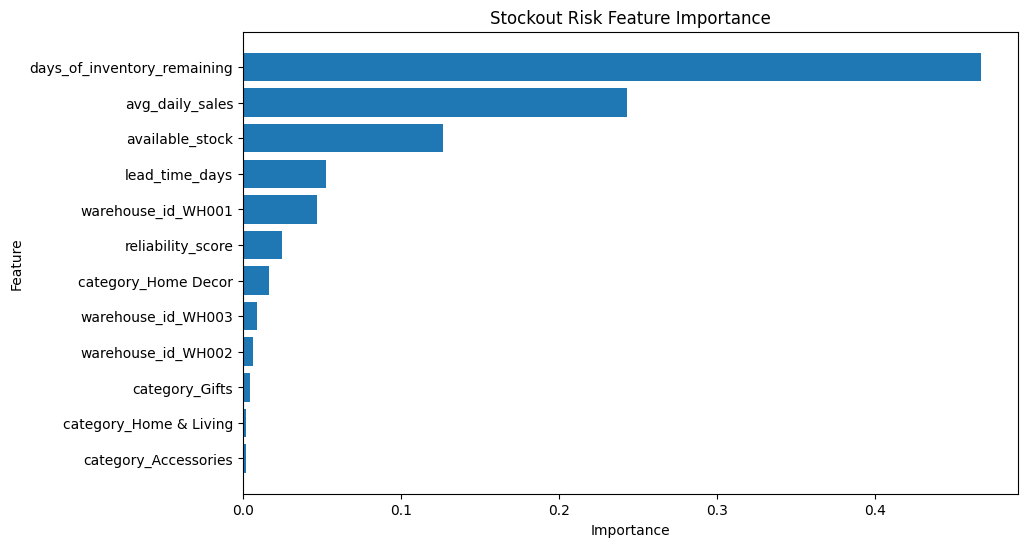

In [0]:
# Train a final Random Forest model for feature importance visualization

final_stockout_model = Pipeline(
    steps=[
        ("preprocessor", stockout_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ))
    ]
)

final_stockout_model.fit(X_train_s, y_train_s)

feature_names = list(
    final_stockout_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features_stockout)
) + numeric_features_stockout

importances = final_stockout_model.named_steps["classifier"].feature_importances_

feature_importance_pd = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_pd)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pd["feature"], feature_importance_pd["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Stockout Risk Feature Importance")
plt.gca().invert_yaxis()
plt.show()

2026/05/18 10:02:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '56ea85e2c55443f68cb7b6afb74eb0c1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
🔗 View Logged Model at: https://dbc-10653d8b-1a71.cloud.databricks.com/ml/experiments/4215696400131599/models/m-6da700508e6043baa8eaee898f3cf0f9?o=7474650489607792


feature,importance
available_stock,0.5175666989996293
warehouse_id_WH001,0.1446235938145029
lead_time_days,0.07518734941959739
reorder_level,0.07466526121577674
category_Home Decor,0.07012883224142172
reorder_quantity,0.03936256480172926
warehouse_id_WH002,0.025473166871916496
warehouse_id_WH003,0.025135540366621474
category_Home & Living,0.01691761657355714
category_Accessories,0.01040479586649611


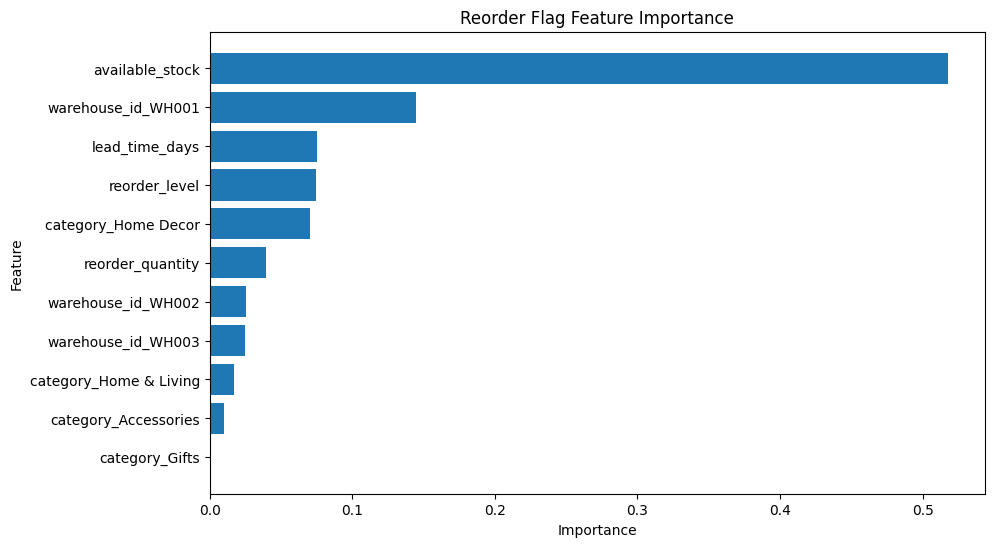

In [0]:
final_reorder_model = Pipeline(
    steps=[
        ("preprocessor", reorder_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ))
    ]
)

final_reorder_model.fit(X_train_r, y_train_r)

feature_names_reorder = list(
    final_reorder_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features_reorder)
) + numeric_features_reorder

importances_reorder = final_reorder_model.named_steps["classifier"].feature_importances_

feature_importance_reorder_pd = pd.DataFrame({
    "feature": feature_names_reorder,
    "importance": importances_reorder
}).sort_values("importance", ascending=False)

display(feature_importance_reorder_pd)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_reorder_pd["feature"], feature_importance_reorder_pd["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Reorder Flag Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Feature Importance Summary

The feature importance charts help explain which inputs influence the model predictions.

For stockout risk, important features may include:

- Days of inventory remaining
- Available stock
- Average daily sales
- Supplier lead time
- Supplier reliability

For reorder prediction, important features may include:

- Available stock
- Reorder level
- Reorder quantity
- Supplier lead time

This makes the models easier to explain to business and technical stakeholders.

# Model Registration

This section registers the selected best models in the Unity Catalog Model Registry.

Unity Catalog model names use a three-level namespace:

catalog.schema.model_name

This project registers two models:

- `workspace.retail_capstone.stockout_risk_classifier`
- `workspace.retail_capstone.reorder_flag_classifier`

Model aliases are used for lifecycle management:

- `challenger`
- `champion`

In [0]:
mlflow.set_registry_uri("databricks-uc")

In [0]:
best_stockout_run_id = best_stockout_run["run_id"]

stockout_model_uri = f"runs:/{best_stockout_run_id}/model"

stockout_registered_model = mlflow.register_model(
    model_uri=stockout_model_uri,
    name="workspace.retail_capstone.stockout_risk_classifier"
)

print("Registered stockout model version:", stockout_registered_model.version)

Successfully registered model 'workspace.retail_capstone.stockout_risk_classifier'.
2026/05/18 10:04:02 WARNING mlflow.tracking._model_registry.fluent: Run with id dda685caa1824be29f4cf4587e728a60 has no artifacts at artifact path 'model', registering model based on models:/m-25e15c78a89e43d882fcba843ed82f93 instead


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

Registered stockout model version: 1


🔗 Created version '1' of model 'workspace.retail_capstone.stockout_risk_classifier': https://dbc-10653d8b-1a71.cloud.databricks.com/explore/data/models/workspace/retail_capstone/stockout_risk_classifier/version/1?o=7474650489607792


In [0]:
best_reorder_run_id = best_reorder_run["run_id"]

reorder_model_uri = f"runs:/{best_reorder_run_id}/model"

reorder_registered_model = mlflow.register_model(
    model_uri=reorder_model_uri,
    name="workspace.retail_capstone.reorder_flag_classifier"
)

print("Registered reorder model version:", reorder_registered_model.version)

Successfully registered model 'workspace.retail_capstone.reorder_flag_classifier'.
2026/05/18 10:05:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 493493bf0c014dd99118baf0a5b940c7 has no artifacts at artifact path 'model', registering model based on models:/m-d398cd4ed6bc42ed80179b4f054e6082 instead


Uploading artifacts:   0%|          | 0/10 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.retail_capstone.reorder_flag_classifier': https://dbc-10653d8b-1a71.cloud.databricks.com/explore/data/models/workspace/retail_capstone/reorder_flag_classifier/version/1?o=7474650489607792


Registered reorder model version: 1


In [0]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

In [0]:
client.set_registered_model_alias(
    name="workspace.retail_capstone.stockout_risk_classifier",
    alias="challenger",
    version=stockout_registered_model.version
)

client.set_registered_model_alias(
    name="workspace.retail_capstone.reorder_flag_classifier",
    alias="challenger",
    version=reorder_registered_model.version
)

In [0]:
client.set_registered_model_alias(
    name="workspace.retail_capstone.stockout_risk_classifier",
    alias="champion",
    version=stockout_registered_model.version
)

client.set_registered_model_alias(
    name="workspace.retail_capstone.reorder_flag_classifier",
    alias="champion",
    version=reorder_registered_model.version
)

In [0]:
stockout_champion_uri = "models:/workspace.retail_capstone.stockout_risk_classifier@champion"

loaded_stockout_model = mlflow.pyfunc.load_model(stockout_champion_uri)

stockout_sample = X_test_s.head(3)

stockout_predictions = loaded_stockout_model.predict(stockout_sample)

print(stockout_predictions)

['High Risk' 'High Risk' 'Medium Risk']


In [0]:
reorder_champion_uri = "models:/workspace.retail_capstone.reorder_flag_classifier@champion"

loaded_reorder_model = mlflow.pyfunc.load_model(reorder_champion_uri)

reorder_sample = X_test_r.head(3)

reorder_predictions = loaded_reorder_model.predict(reorder_sample)

print(reorder_predictions)

['Reorder Needed' 'Reorder Needed' 'Reorder Needed']


# Model Registration Summary

The best stockout risk classifier and reorder flag classifier were registered in Unity Catalog Model Registry.

Registered models:

- `workspace.retail_capstone.stockout_risk_classifier`
- `workspace.retail_capstone.reorder_flag_classifier`

Both models were first assigned the `@challenger` alias.

After validation, the same versions were promoted to the `@champion` alias.

The `@champion` alias identifies the production candidate model version that can be used for serving.